In [ ]:
# wetland probability analysis

### **Per-Wetland Probability Calculation Script (`uai_per_wetland_probabilities.py`)**

This script computes, for every historical wetland in the dataset, the **probability that uplands outperform wetlands** in August based on the Upland Advantage Index (UAI):

UAI = (EVI2_upland) - (EVI2_wetland)


Using the cached August UAI dataset (`UAI_prepped_AUGUST.csv`), the script evaluates the fraction of years between **2003–2024** in which each wetland has a UAI value exceeding one or more user-defined thresholds (e.g., 0.00, 0.01, 0.02). These thresholds represent different definitions of “upland advantage,” ranging from *any* positive difference (τ = 0) to more stringent measures of meaningful difference.

For each wetland × crop combination with sufficient temporal coverage (default: ≥5 years), the script calculates:

* the number of valid years of UAI observations
* the probability that UAI exceeds each threshold
* both **wide-format** and **long-format** outputs summarizing these probabilities

The script saves two output files:

* **`UAI_per_wetland_probs_wide.csv`** – one row per wetland × crop, with probability columns for each threshold
* **`UAI_per_wetland_probs_long.csv`** – tidy/long format with one row per wetland × crop × threshold

These outputs provide the foundational dataset used for subsequent visualizations, including the stand-alone histogram of per-wetland P(UAI > 0).


In [3]:
#!/usr/bin/env python3
# uai_per_wetland_probabilities.py
#
# For each historical wetland, compute the fraction of years during
# 2003–2024 in which the upland has a UAI value greater than one or
# more user-defined thresholds:
#
#   UAI = mean(EVI2 upland) − mean(EVI2 wetland)
#
# Example thresholds:
#   0.00 → any upland advantage
#   0.01, 0.02 → "meaningful" upland advantage
#
# Outputs:
#   - UAI_per_wetland_probs_wide.csv
#   - UAI_per_wetland_probs_long.csv
#
# Author: Kimberly Van Meter

from pathlib import Path
import numpy as np
import pandas as pd
import os

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------

# Folder where cached UAI data and figures live
OUT_ROOT = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "NDVI_wetlands_figures"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# Cached August UAI CSV (created by earlier scripts)
CACHE_CSV = OUT_ROOT / "UAI_prepped_AUGUST.csv"

# Wetland ID column in the cached file
# Change this if your unique wetland identifier is different (e.g., "label")
WETLAND_ID_COL = "dir"

# Thresholds for "upland advantage"
# You can freely adjust this list
THRESHOLDS = [0.0, 0.01, 0.02]

# Minimum number of valid years required for a wetland × crop
MIN_YEARS = 5

# Output paths
OUT_WIDE = OUT_ROOT / "UAI_per_wetland_probs_wide.csv"
OUT_LONG = OUT_ROOT / "UAI_per_wetland_probs_long.csv"


# ------------------------------------------------------------
# CORE FUNCTION
# ------------------------------------------------------------

def compute_per_wetland_probabilities(
    df: pd.DataFrame,
    thresholds: list[float],
    id_col: str,
    min_years: int = 5,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    For each wetland (id_col) and crop, compute:

        n_years       = number of years with non-NaN UAI
        p_gt_tau      = fraction of years with UAI > tau  (for each tau)

    Returns:
        wide_df: one row per wetland × crop, columns:
                 [id_col, crop, n_years, p_gt_0.000, p_gt_0.010, ...]
        long_df: long/tidy version, columns:
                 [id_col, crop, n_years, threshold, prob]
    """

    df = df.copy()
    if id_col not in df.columns:
        raise KeyError(f"Column '{id_col}' not found in dataframe.")

    # Ensure types
    df["crop"] = df["crop"].astype(str)
    df["year"] = df["year"].astype(int)

    # Group by wetland × crop
    grp = df.groupby([id_col, "crop"], dropna=False)

    rows_wide = []
    rows_long = []

    thresholds_sorted = sorted(thresholds)

    for (wid, crop), sub in grp:
        u = sub["UAI"].dropna()
        n_years = u.size
        if n_years < min_years:
            # Skip wetlands with too little temporal coverage
            continue

        # Row for wide format
        row = {id_col: wid, "crop": crop, "n_years": n_years}

        for tau in thresholds_sorted:
            prob = float((u > tau).mean())
            colname = f"p_gt_{tau:.3f}"
            row[colname] = prob

            rows_long.append(
                {
                    id_col: wid,
                    "crop": crop,
                    "n_years": n_years,
                    "threshold": tau,
                    "prob": prob,
                }
            )

        rows_wide.append(row)

    if not rows_wide:
        raise ValueError("No wetland × crop groups met the minimum year requirement.")

    wide_df = pd.DataFrame(rows_wide)
    long_df = pd.DataFrame(rows_long)

    return wide_df, long_df


# ------------------------------------------------------------
# MAIN
# ------------------------------------------------------------

def main():
    # Load cached August UAI dataframe
    if not CACHE_CSV.exists():
        raise FileNotFoundError(
            f"Cached UAI file not found: {CACHE_CSV}\n"
            "Run the UAI preparation script first."
        )

    df = pd.read_csv(CACHE_CSV)

    required_cols = {WETLAND_ID_COL, "crop", "year", "UAI"}
    missing = required_cols.difference(df.columns)
    if missing:
        raise KeyError(f"Cached CSV is missing required columns: {missing}")

    # Compute per-wetland probabilities
    wide_df, long_df = compute_per_wetland_probabilities(
        df,
        thresholds=THRESHOLDS,
        id_col=WETLAND_ID_COL,
        min_years=MIN_YEARS,
    )

    # Save outputs
    wide_df.to_csv(OUT_WIDE, index=False)
    long_df.to_csv(OUT_LONG, index=False)

    print(f"[INFO] Wide per-wetland probabilities → {OUT_WIDE}")
    print(f"[INFO] Long per-wetland probabilities → {OUT_LONG}")
    print(f"[INFO] # wetlands (rows, wide): {len(wide_df)}")
    print(f"[INFO] Thresholds used: {THRESHOLDS}")


if __name__ == "__main__":
    main()


[INFO] Wide per-wetland probabilities → /Users/kbv5173/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/UAI_per_wetland_probs_wide.csv
[INFO] Long per-wetland probabilities → /Users/kbv5173/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/UAI_per_wetland_probs_long.csv
[INFO] # wetlands (rows, wide): 2
[INFO] Thresholds used: [0.0, 0.01, 0.02]


In [2]:
#!/usr/bin/env python3
# uai_per_wetland_probabilities_label.py
#
# Recompute per-wetland probabilities using `label` as the wetland ID:
#
#   UAI = mean(EVI2 upland) − mean(EVI2 wetland)
#
# For each (label, crop), compute the fraction of years with
#   UAI > τ  for each threshold τ.
#
# Outputs (OVERWRITES previous versions):
#   - UAI_per_wetland_probs_wide.csv
#   - UAI_per_wetland_probs_long.csv
#
# Author: Kimberly Van Meter

from pathlib import Path
import numpy as np
import pandas as pd
import os

# ------------------------------------------------------------
# PATHS & SETTINGS
# ------------------------------------------------------------

OUT_ROOT = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "NDVI_wetlands_figures"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

CACHE_CSV = OUT_ROOT / "UAI_prepped_AUGUST.csv"

# Use `label` as the true wetland ID
WETLAND_ID_COL = "label"

# Thresholds you want to track (you can edit this list anytime)
THRESHOLDS = [0.0, 0.01, 0.02]

# Minimum number of valid years required per wetland × crop
MIN_YEARS = 5

OUT_WIDE = OUT_ROOT / "UAI_per_wetland_probs_wide.csv"
OUT_LONG = OUT_ROOT / "UAI_per_wetland_probs_long.csv"


# ------------------------------------------------------------
# CORE FUNCTION
# ------------------------------------------------------------

def compute_per_wetland_probabilities(
    df: pd.DataFrame,
    thresholds: list[float],
    id_col: str,
    min_years: int = 5,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    For each wetland (id_col) and crop, compute:

        n_years           = number of years with non-NaN UAI
        p_gt_tau (per τ)  = fraction of years with UAI > τ

    Returns:
        wide_df: one row per wetland × crop, columns:
                 [id_col, crop, n_years, p_gt_0.000, p_gt_0.010, ...]
        long_df: long/tidy version, columns:
                 [id_col, crop, n_years, threshold, prob]
    """

    df = df.copy()

    if id_col not in df.columns:
        raise KeyError(f"Column '{id_col}' not found in dataframe.")

    df["crop"] = df["crop"].astype(str)
    df["year"] = df["year"].astype(int)

    grp = df.groupby([id_col, "crop"], dropna=False)

    rows_wide = []
    rows_long = []

    thresholds_sorted = sorted(thresholds)

    for (wid, crop), sub in grp:
        u = sub["UAI"].dropna()
        n_years = u.size
        if n_years < min_years:
            continue

        row = {id_col: wid, "crop": crop, "n_years": n_years}

        for tau in thresholds_sorted:
            prob = float((u > tau).mean())
            colname = f"p_gt_{tau:.3f}"
            row[colname] = prob

            rows_long.append(
                {
                    id_col: wid,
                    "crop": crop,
                    "n_years": n_years,
                    "threshold": tau,
                    "prob": prob,
                }
            )

        rows_wide.append(row)

    if not rows_wide:
        raise ValueError(
            "No wetland × crop groups met the minimum year requirement. "
            "Consider lowering MIN_YEARS."
        )

    wide_df = pd.DataFrame(rows_wide)
    long_df = pd.DataFrame(rows_long)

    return wide_df, long_df


# ------------------------------------------------------------
# MAIN
# ------------------------------------------------------------

def main():
    if not CACHE_CSV.exists():
        raise FileNotFoundError(
            f"Cached UAI file not found: {CACHE_CSV}\n"
            "Run the August UAI preparation script first."
        )

    df = pd.read_csv(CACHE_CSV)

    required_cols = {WETLAND_ID_COL, "crop", "year", "UAI"}
    missing = required_cols.difference(df.columns)
    if missing:
        raise KeyError(f"Cached CSV is missing required columns: {missing}")

    wide_df, long_df = compute_per_wetland_probabilities(
        df,
        thresholds=THRESHOLDS,
        id_col=WETLAND_ID_COL,
        min_years=MIN_YEARS,
    )

    wide_df.to_csv(OUT_WIDE, index=False)
    long_df.to_csv(OUT_LONG, index=False)

    print(f"[INFO] Wide per-wetland probabilities → {OUT_WIDE}")
    print(f"[INFO] Long per-wetland probabilities → {OUT_LONG}")
    print(f"[INFO] # wetland×crop rows (wide): {len(wide_df)}")
    print(f"[INFO] Thresholds used: {THRESHOLDS}")


if __name__ == "__main__":
    main()


[INFO] Wide per-wetland probabilities → /Users/kbv5173/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/UAI_per_wetland_probs_wide.csv
[INFO] Long per-wetland probabilities → /Users/kbv5173/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/UAI_per_wetland_probs_long.csv
[INFO] # wetland×crop rows (wide): 236319
[INFO] Thresholds used: [0.0, 0.01, 0.02]


[INFO] Wide per-wetland probabilities (no crop) → /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/UAI_per_wetland_probs_nocrop_wide.csv
[INFO] Long per-wetland probabilities (no crop) → /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/UAI_per_wetland_probs_nocrop_long.csv
[INFO] # wetlands (rows, wide): 138534
[INFO] Thresholds used: [0.0, 0.01, 0.02]
[SAVED] /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/Figure_perWetlandProb_nocrop_hist.png
[SAVED] /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/Figure_perWetlandProb_nocrop_hist.jpg


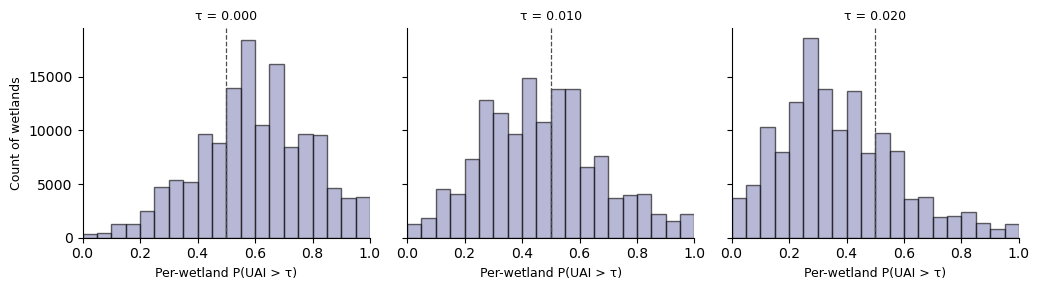

In [7]:
#!/usr/bin/env python3
# uai_per_wetland_probabilities_nocrop.py
#
# For each historical wetland (label), compute the fraction of
# year–crop observations with:
#
#   UAI = mean(EVI2 upland) − mean(EVI2 wetland)
#
# greater than one or more thresholds τ, regardless of whether
# the surrounding crop is corn or soy.
#
# Outputs:
#   - UAI_per_wetland_probs_nocrop_wide.csv
#   - UAI_per_wetland_probs_nocrop_long.csv
#   - Figure_perWetlandProb_nocrop_hist.png / .jpg
#
# Author: Kimberly Van Meter

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# ------------------------------------------------------------
# PATHS & SETTINGS
# ------------------------------------------------------------

OUT_ROOT = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "NDVI_wetlands_figures"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# Cached August UAI data
CACHE_CSV = OUT_ROOT / "UAI_prepped_AUGUST.csv"

# Wetland identifier
WETLAND_ID_COL = "label"

# Thresholds τ for "upland advantage" (edit as needed)
THRESHOLDS = [0.0, 0.01, 0.02]

# Minimum number of UAI observations per wetland (across all years/crops)
MIN_OBS = 5

# Output data files
OUT_WIDE = OUT_ROOT / "UAI_per_wetland_probs_nocrop_wide.csv"
OUT_LONG = OUT_ROOT / "UAI_per_wetland_probs_nocrop_long.csv"

# Output figure
FIG_PNG = OUT_ROOT / "Figure_perWetlandProb_nocrop_hist.png"
FIG_JPG = OUT_ROOT / "Figure_perWetlandProb_nocrop_hist.jpg"

# Histogram bins
BINS = np.linspace(0, 1, 21)


# ------------------------------------------------------------
# CORE CALCULATION
# ------------------------------------------------------------

def compute_per_wetland_probs_nocrop(
    df: pd.DataFrame,
    thresholds: list[float],
    id_col: str,
    min_obs: int = 5,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    For each wetland (id_col), ignoring crop, compute:

        n_obs          = number of non-NaN UAI observations (all years, all crops)
        p_gt_tau (τ)   = fraction of observations with UAI > τ

    Returns:
        wide_df: one row per wetland, columns:
                 [id_col, n_obs, p_gt_0.000, p_gt_0.010, ...]
        long_df: tidy version, columns:
                 [id_col, n_obs, threshold, prob]
    """

    df = df.copy()

    if id_col not in df.columns:
        raise KeyError(f"Column '{id_col}' not found in dataframe.")

    thresholds_sorted = sorted(thresholds)

    # Group only by wetland label; crop is ignored
    grp = df.groupby(id_col, dropna=False)

    rows_wide = []
    rows_long = []

    for wid, sub in grp:
        u = sub["UAI"].dropna()
        n_obs = u.size
        if n_obs < min_obs:
            continue

        row = {id_col: wid, "n_obs": n_obs}

        for tau in thresholds_sorted:
            prob = float((u > tau).mean())
            colname = f"p_gt_{tau:.3f}"
            row[colname] = prob

            rows_long.append(
                {
                    id_col: wid,
                    "n_obs": n_obs,
                    "threshold": tau,
                    "prob": prob,
                }
            )

        rows_wide.append(row)

    if not rows_wide:
        raise ValueError(
            "No wetlands met the minimum observation requirement. "
            "Consider lowering MIN_OBS."
        )

    wide_df = pd.DataFrame(rows_wide)
    long_df = pd.DataFrame(rows_long)

    return wide_df, long_df


# ------------------------------------------------------------
# PLOTTING
# ------------------------------------------------------------

def plot_histograms_nocrop(df_long: pd.DataFrame) -> None:
    """
    Make a small grid of histograms of per-wetland probability
    P_wetland(UAI > τ), for each threshold τ. No crop separation.
    """

    df = df_long.copy()
    taus = sorted(df["threshold"].unique())
    n_cols = len(taus)

    figsize = (3.5 * n_cols, 3.0)
    fig, axes = plt.subplots(1, n_cols, figsize=figsize, sharey=True)

    if n_cols == 1:
        axes = np.array([axes])

    for j, tau in enumerate(taus):
        ax = axes[j]

        vals = df[df["threshold"] == tau]["prob"].dropna().values

        if vals.size == 0:
            ax.text(
                0.5, 0.5, "No data",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=8,
            )
            ax.set_axis_off()
            continue

        ax.hist(
            vals,
            bins=BINS,
            color="#8888bb",
            edgecolor="black",
            alpha=0.6,
        )

        # Reference line at 0.5
        ax.axvline(0.5, color="0.3", linestyle="--", linewidth=0.9)

        ax.set_xlim(0, 1)
        ax.set_xlabel("Per-wetland P(UAI > τ)", fontsize=9)
        ax.set_title(f"τ = {tau:.3f}", fontsize=9)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if j == 0:
            ax.set_ylabel("Count of wetlands", fontsize=9)

    plt.tight_layout()
    fig.savefig(FIG_PNG, dpi=300)
    fig.savefig(FIG_JPG, dpi=300)
    print(f"[SAVED] {FIG_PNG}")
    print(f"[SAVED] {FIG_JPG}")


# ------------------------------------------------------------
# MAIN
# ------------------------------------------------------------

def main():
    if not CACHE_CSV.exists():
        raise FileNotFoundError(
            f"Cached UAI file not found: {CACHE_CSV}\n"
            "Run the UAI preparation script first."
        )

    df = pd.read_csv(CACHE_CSV)

    required_cols = {WETLAND_ID_COL, "UAI"}
    missing = required_cols.difference(df.columns)
    if missing:
        raise KeyError(f"Cached CSV is missing required columns: {missing}")

    wide_df, long_df = compute_per_wetland_probs_nocrop(
        df,
        thresholds=THRESHOLDS,
        id_col=WETLAND_ID_COL,
        min_obs=MIN_OBS,
    )

    wide_df.to_csv(OUT_WIDE, index=False)
    long_df.to_csv(OUT_LONG, index=False)

    print(f"[INFO] Wide per-wetland probabilities (no crop) → {OUT_WIDE}")
    print(f"[INFO] Long per-wetland probabilities (no crop) → {OUT_LONG}")
    print(f"[INFO] # wetlands (rows, wide): {len(wide_df)}")
    print(f"[INFO] Thresholds used: {THRESHOLDS}")

    plot_histograms_nocrop(long_df)


if __name__ == "__main__":
    main()


### **Histogram of Per-Wetland Probability of Upland Advantage (`uai_per_wetland_prob_hist_tau0.py`)**

This script generates a single, publication-ready histogram summarizing the **per-wetland probability that uplands outperform wetlands** in August based on the Upland Advantage Index (UAI). It uses the long-format probability file created by the upstream per-wetland probability script (`UAI_per_wetland_probs_nocrop_long.csv`) and extracts the probability associated with the **τ = 0** threshold—representing *any* positive upland advantage.

The script performs the following steps:

1. **Loads** the long-format dataset containing per-wetland probabilities across thresholds.
2. **Filters** the data to retain only probabilities where UAI > 0 (τ = 0).
3. **Computes summary statistics**, including the percentage of wetlands with

   * P(UAI > 0) > 0.5
   * P(UAI > 0) > 0.75
4. **Creates a histogram** showing the distribution of P(UAI > 0) across all wetlands, using 20 equally spaced bins between 0 and 1.
5. **Adds a reference line** at 0.5 to highlight wetlands that more often than not exhibit upland underperformance.
6. **Applies publication-style aesthetics**, including a full bounding box and consistent formatting.
7. **Saves the figure** in both PNG and JPG formats.

This script is a *plot-only* workflow: it does not compute UAI values itself but relies entirely on the precomputed long-format probability table. It provides a clear, interpretable visualization of the overall strength and prevalence of upland advantage across the wetland dataset.


[INFO] Loaded 415602 rows of per-wetland probabilities.
[INFO] 66.8% of wetlands have wetland underperformance in >50% of years (92541 of 138534).
[INFO] 20.1% of wetlands have wetland underperformance in >75% of years (27902 of 138534).
[SAVED] /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/Figure_perWetlandPercentUnderperf_tau0_only.png
[SAVED] /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/Figure_perWetlandPercentUnderperf_tau0_only.jpg


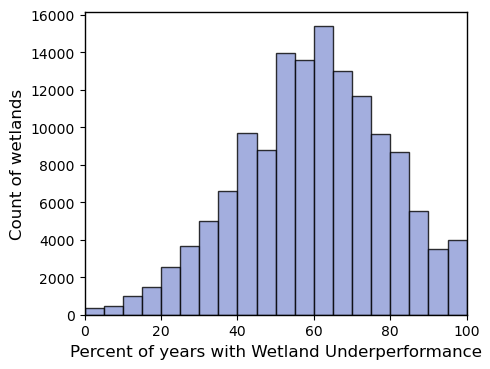

In [12]:
#!/usr/bin/env python3
# uai_per_wetland_underperf_percent_hist.py
#
# Histogram of percent of years with wetland underperformance,
# i.e., percent of years with UAI > 0, ignoring crop and using
# all available years.
#
# Author: Kimberly Van Meter

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# ------------------------------------------------------------
# PATHS & SETTINGS
# ------------------------------------------------------------

OUT_ROOT = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "NDVI_wetlands_figures"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

LONG_CSV = OUT_ROOT / "UAI_per_wetland_probs_nocrop_long.csv"

FIG_PNG = OUT_ROOT / "Figure_perWetlandPercentUnderperf_tau0_only.png"
FIG_JPG = OUT_ROOT / "Figure_perWetlandPercentUnderperf_tau0_only.jpg"

ID_COL = "label"

# Histogram bins in PERCENT (0–100)
BINS = np.linspace(0, 100, 21)

# Color
COLOR = "#8C9AD6"   # adjust if you want something earthier


# ------------------------------------------------------------
# MAIN PLOT
# ------------------------------------------------------------

def plot_single_hist_tau0(df_long: pd.DataFrame) -> None:
    """
    Make a clean histogram of the percent of years with wetland
    underperformance (UAI > 0), ignoring crop.

    Also prints the percentage of wetlands with:
        - >50% of years showing underperformance
        - >75% of years showing underperformance
    """

    tau0 = 0.0
    sub = df_long[df_long["threshold"] == tau0]

    probs = sub["prob"].dropna().values

    if probs.size == 0:
        raise ValueError("No per-wetland probabilities found for τ = 0.")

    # Convert fractional probabilities (0–1) to percent (0–100)
    vals_pct = probs * 100.0

    # Summary statistics in terms of % of years
    n_total = vals_pct.size

    n_hi_50 = np.sum(vals_pct > 50.0)
    pct_wetlands_hi_50 = 100.0 * n_hi_50 / n_total
    print(
        f"[INFO] {pct_wetlands_hi_50:.1f}% of wetlands have "
        f"wetland underperformance in >50% of years "
        f"({n_hi_50} of {n_total})."
    )

    n_hi_75 = np.sum(vals_pct > 75.0)
    pct_wetlands_hi_75 = 100.0 * n_hi_75 / n_total
    print(
        f"[INFO] {pct_wetlands_hi_75:.1f}% of wetlands have "
        f"wetland underperformance in >75% of years "
        f"({n_hi_75} of {n_total})."
    )

    # --- FIGURE ---
    figsize = (5.0, 3.8)
    fig, ax = plt.subplots(figsize=figsize)

    ax.hist(
        vals_pct,
        bins=BINS,
        color=COLOR,
        edgecolor="black",
        alpha=0.8,
    )

    # Aesthetics
    ax.set_xlim(0, 100)
    ax.set_xlabel(
        "Percent of years with Wetland Underperformance",
        fontsize=12,
    )
    ax.set_ylabel("Count of wetlands", fontsize=12)

    # Full bounding box (all spines visible)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)

    plt.tight_layout()
    fig.savefig(FIG_PNG, dpi=300)
    fig.savefig(FIG_JPG, dpi=300)
    print(f"[SAVED] {FIG_PNG}")
    print(f"[SAVED] {FIG_JPG}")


# ------------------------------------------------------------
# MAIN
# ------------------------------------------------------------

def main():
    if not LONG_CSV.exists():
        raise FileNotFoundError(
            f"Per-wetland long CSV not found:\n  {LONG_CSV}\n"
            "Run the per-wetland no-crop probability script first."
        )

    df_long = pd.read_csv(LONG_CSV)

    required = {ID_COL, "threshold", "prob"}
    missing = required.difference(df_long.columns)
    if missing:
        raise KeyError(f"Long CSV missing required columns: {missing}")

    print(f"[INFO] Loaded {len(df_long)} rows of per-wetland probabilities.")

    plot_single_hist_tau0(df_long)


if __name__ == "__main__":
    main()


[INFO] Loaded 415602 rows.
[SAVED] /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/Figure_perWetlandUnderperf_hist_CDF.png
[SAVED] /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/Figure_perWetlandUnderperf_hist_CDF.jpg


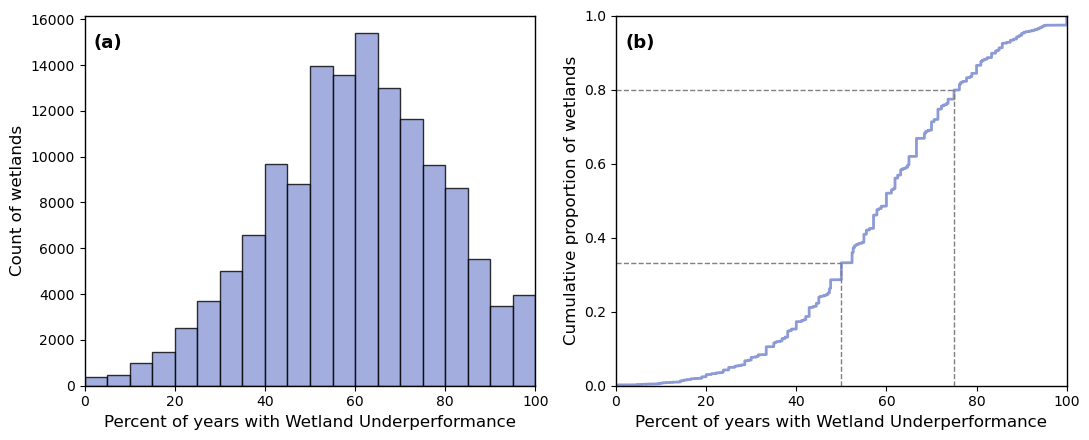

In [19]:
#!/usr/bin/env python3
# uai_per_wetland_underperf_hist_cdf.py
#
# Two-panel figure:
#   (a) Histogram of percent of years with wetland underperformance
#   (b) Empirical CDF of percent of years with wetland underperformance
#
# Author: Kimberly Van Meter

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

OUT_ROOT = Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "NDVI_wetlands_figures"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

LONG_CSV = OUT_ROOT / "UAI_per_wetland_probs_nocrop_long.csv"

FIG_PNG = OUT_ROOT / "Figure_perWetlandUnderperf_hist_CDF.png"
FIG_JPG = OUT_ROOT / "Figure_perWetlandUnderperf_hist_CDF.jpg"

ID_COL = "label"

# Histogram bins (0–100%)
BINS = np.linspace(0, 100, 21)

# Color
COLOR = "#8C9AD6"


# ------------------------------------------------------------
# PLOT FUNCTION
# ------------------------------------------------------------

def make_two_panel_plot(df_long: pd.DataFrame):
    """
    Creates a two-panel figure:
        (a) histogram of % years with wetland underperformance
        (b) cumulative distribution function (CDF)
    """

    # Filter to tau = 0
    tau0 = 0.0
    sub = df_long[df_long["threshold"] == tau0]

    probs = sub["prob"].dropna().values
    if probs.size == 0:
        raise ValueError("No probabilities for τ = 0.")

    # Convert to percent
    vals_pct = probs * 100.0
    vals_sorted = np.sort(vals_pct)
    n = vals_sorted.size
    cdf = np.arange(1, n + 1) / n

    # Set up figure
    figsize = (11, 4.5)
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    plt.subplots_adjust(wspace=0.3)

    # ------------------------------------------------------------
    # (a) HISTOGRAM
    # ------------------------------------------------------------
    ax = axes[0]

    ax.hist(
        vals_pct,
        bins=BINS,
        color=COLOR,
        edgecolor="black",
        alpha=0.8,
    )

    ax.set_xlim(0, 100)
    ax.set_xlabel("Percent of years with Wetland Underperformance", fontsize=12)
    ax.set_ylabel("Count of wetlands", fontsize=12)

    # Full bounding box
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)

    ax.text(
        0.02, 0.95, "(a)",
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        va="top"
    )

    # ------------------------------------------------------------
    # (b) CDF
    # ------------------------------------------------------------
    ax2 = axes[1]

    ax2.plot(vals_sorted, cdf, color=COLOR, linewidth=2.0)

    # ---- Compute the CDF values at x = 50 and x = 75 ----
    cdf_50 = np.interp(50, vals_sorted, cdf)
    cdf_75 = np.interp(75, vals_sorted, cdf)

    # ---- Add connecting guide lines ----
    # 75% of wetlands underperform in >50% of years
    ax2.axvline(50, ymin=0, ymax=cdf_50, color="0.5", linestyle="--", linewidth=1)
    ax2.plot([0, 50], [cdf_50, cdf_50], color="0.5", linestyle="--", linewidth=1)

    # 25% of wetlands underperform in >75% of years
    ax2.axvline(75, ymin=0, ymax=cdf_75, color="0.5", linestyle="--", linewidth=1)
    ax2.plot([0, 75], [cdf_75, cdf_75], color="0.5", linestyle="--", linewidth=1)

    # Axes formatting
    ax2.set_xlim(0, 100)
    ax2.set_ylim(0, 1)

    ax2.set_xlabel(
        "Percent of years with Wetland Underperformance",
        fontsize=12,
        labelpad=4,
    )
    ax2.set_ylabel("Cumulative proportion of wetlands", fontsize=12)

    for spine in ax2.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)

    ax2.text(
        0.02, 0.95, "(b)",
        transform=ax2.transAxes,
        fontsize=13,
        fontweight="bold",
        va="top"
    )

    # --------------------------------------------------------
    # Save figure
    # --------------------------------------------------------
    plt.tight_layout()
    fig.savefig(FIG_PNG, dpi=300)
    fig.savefig(FIG_JPG, dpi=300)
    print(f"[SAVED] {FIG_PNG}")
    print(f"[SAVED] {FIG_JPG}")


# ------------------------------------------------------------
# MAIN
# ------------------------------------------------------------

def main():
    if not LONG_CSV.exists():
        raise FileNotFoundError(f"Missing long CSV: {LONG_CSV}")

    df_long = pd.read_csv(LONG_CSV)

    required = {ID_COL, "threshold", "prob"}
    missing = required.difference(df_long.columns)
    if missing:
        raise KeyError(f"Missing columns: {missing}")

    print(f"[INFO] Loaded {len(df_long)} rows.")
    make_two_panel_plot(df_long)


if __name__ == "__main__":
    main()
